In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 200
Columns: 5


In [6]:
print(df.columns.tolist())

['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


In [7]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [8]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [10]:
df.describe(include="all")

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [11]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [12]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

Unnamed: 0    0.0
TV            0.0
Radio         0.0
Newspaper     0.0
Sales         0.0
dtype: float64

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['unnamed:_0', 'tv', 'radio', 'newspaper', 'sales'], dtype='str')

In [15]:
df.columns.tolist()

['unnamed:_0', 'tv', 'radio', 'newspaper', 'sales']

In [16]:
df.isnull().sum()

unnamed:_0    0
tv            0
radio         0
newspaper     0
sales         0
dtype: int64

In [17]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Sales Distribution

The distribution of sales is visualized to understand the range and overall
pattern of sales values.

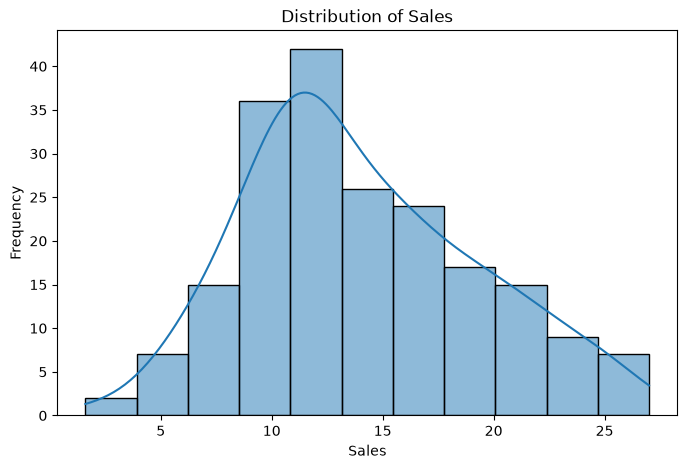

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["sales"], kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

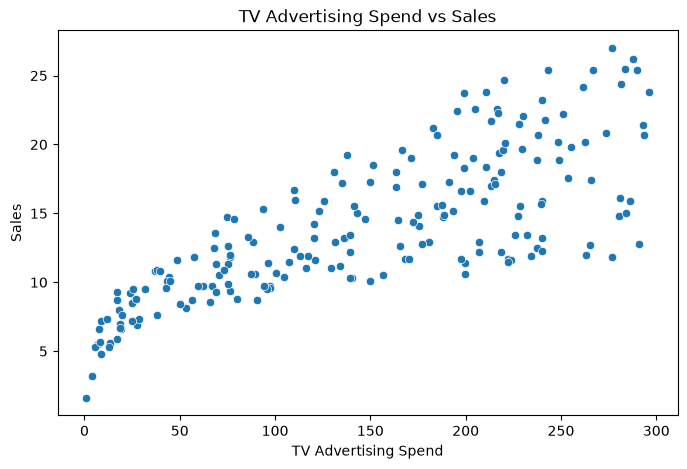

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="tv",
    y="sales"
)

plt.title("TV Advertising Spend vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

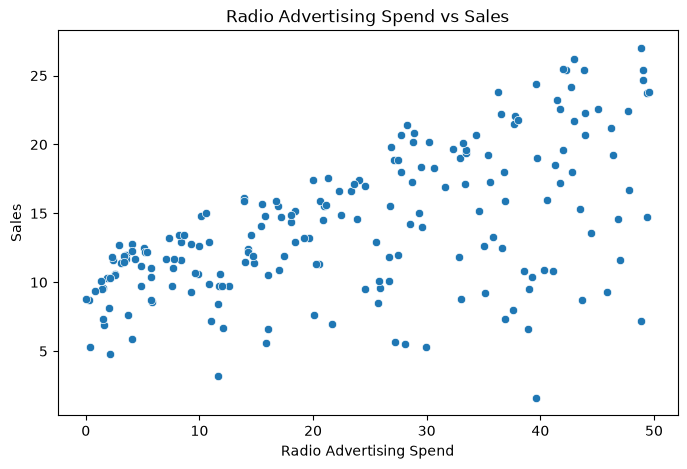

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="radio",
    y="sales"
)

plt.title("Radio Advertising Spend vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

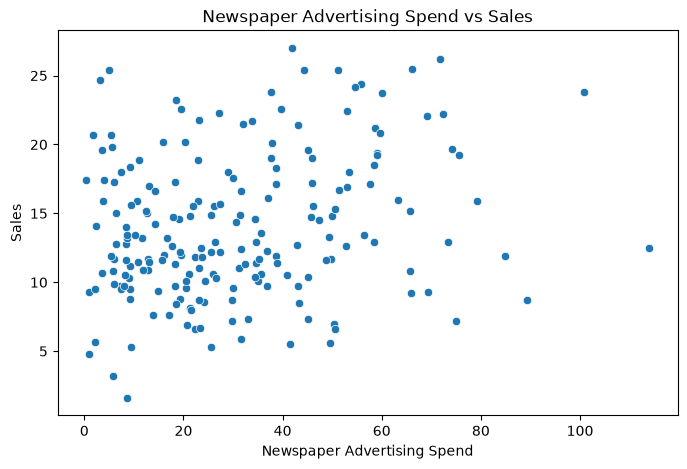

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="newspaper",
    y="sales"
)

plt.title("Newspaper Advertising Spend vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

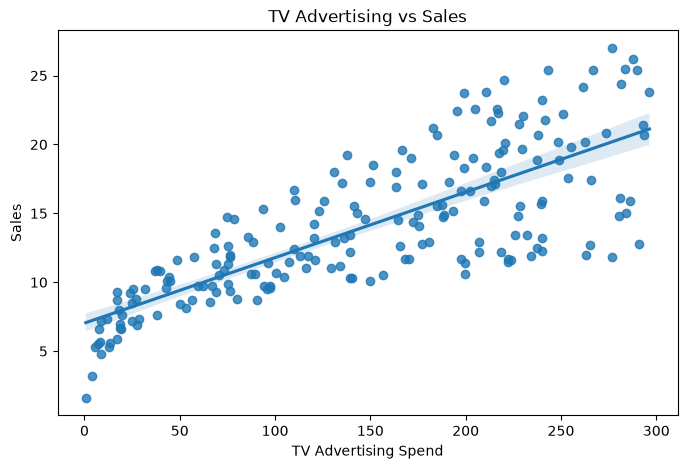

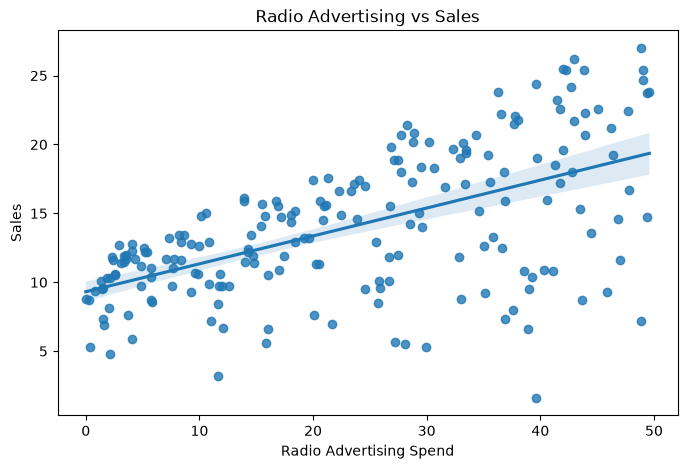

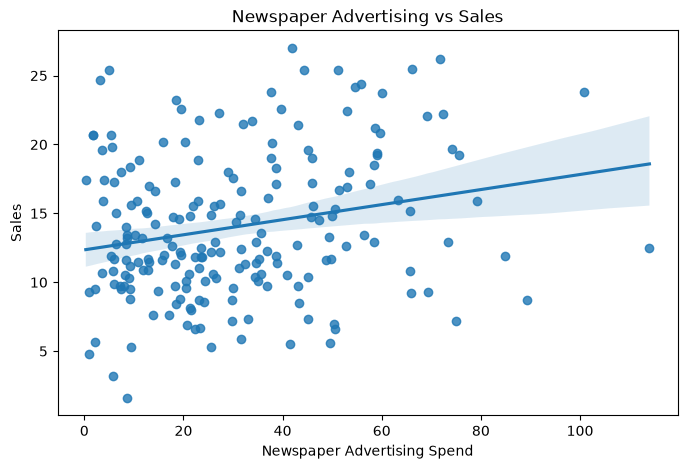

In [23]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="tv",
    y="sales"
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="radio",
    y="sales"
)

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="newspaper",
    y="sales"
)

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()



In [24]:
correlation = df.corr()

correlation

,unnamed:_0,tv,radio,newspaper,sales
unnamed:_0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
tv,0.017715,1.000000,0.054809,0.056648,0.782224
radio,-0.110680,0.054809,1.000000,0.354104,0.576223
newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
sales,-0.051616,0.782224,0.576223,0.228299,1.000000


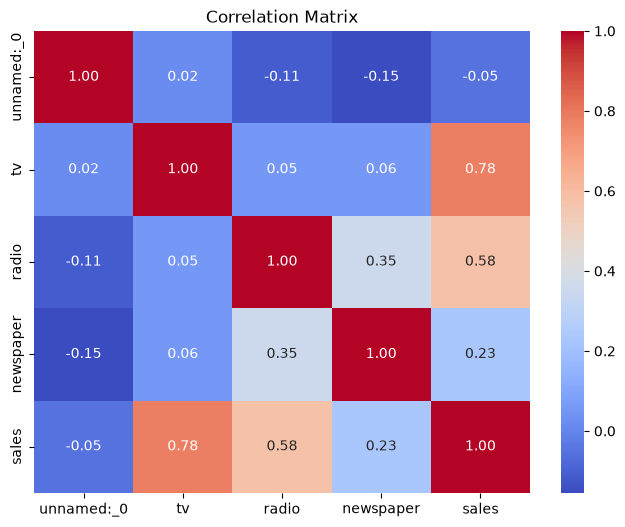

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [26]:
advertising_means = df[
    ["tv", "radio", "newspaper"]
].mean()

advertising_means

tv           147.0425
radio         23.2640
newspaper     30.5540
dtype: float64

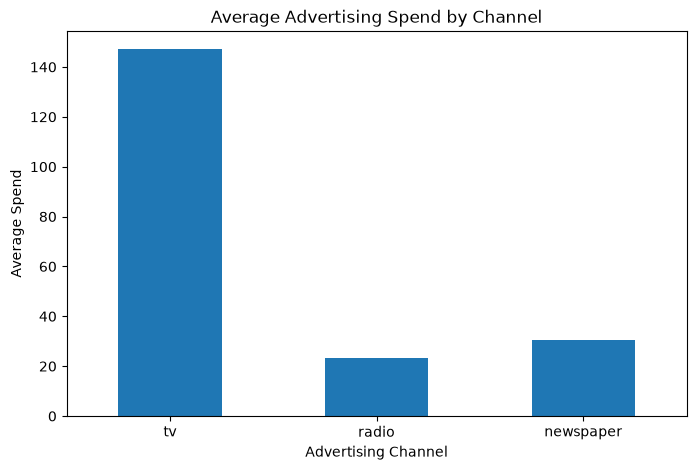

In [27]:
advertising_means.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Advertising Spend by Channel")
plt.xlabel("Advertising Channel")
plt.ylabel("Average Spend")

plt.xticks(rotation=0)

plt.show()

In [29]:
X = df[
    ["tv", "radio", "newspaper"]
]

y = df["sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      tv  radio  newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (160, 3)
Testing data : (40, 3)


In [31]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [32]:
y_pred = linear_model.predict(X_test)

y_pred[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Model Evaluation")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
----------------
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912


In [34]:
print("Intercept:", linear_model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(
    X.columns,
    linear_model.coef_
):
    print(feature, ":", coefficient)

Intercept: 2.979067338122629

Coefficients:
tv : 0.044729517468716326
radio : 0.18919505423437652
newspaper : 0.0027611143413671935


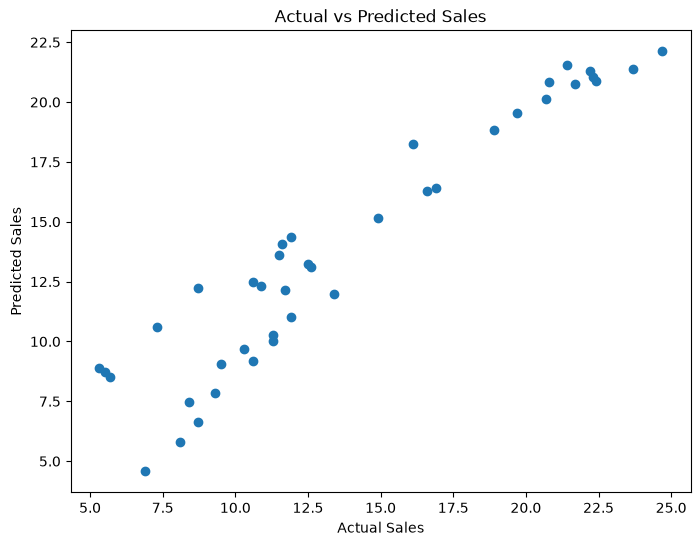

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

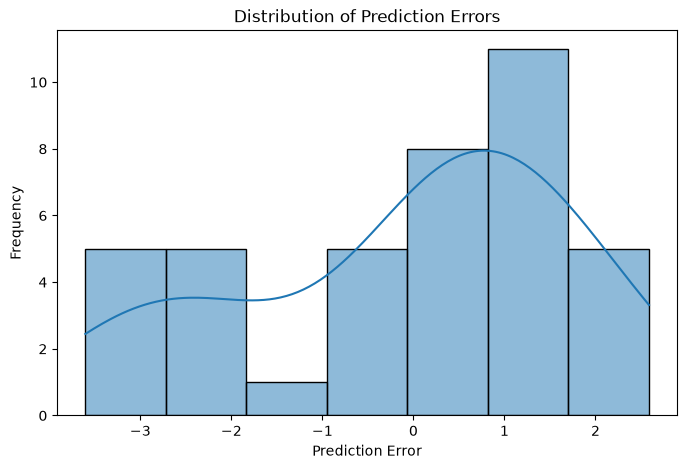

In [37]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    errors,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [38]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,tv,0.044730
1,radio,0.189195
2,newspaper,0.002761


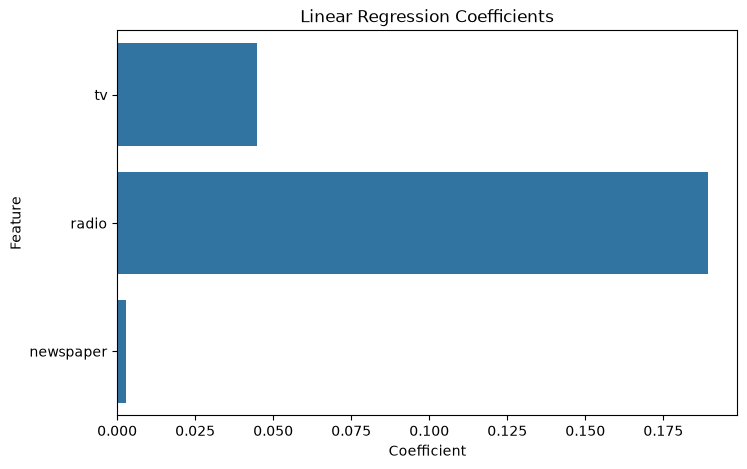

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")

plt.show()

In [41]:
print("TV-Sales correlation:",
      df["tv"].corr(df["sales"]))

print("Radio-Sales correlation:",
      df["radio"].corr(df["sales"]))

print("Newspaper-Sales correlation:",
      df["newspaper"].corr(df["sales"]))

advertising_correlation = pd.DataFrame({
    "Advertising Channel": [
        "TV",
        "Radio",
        "Newspaper"
    ],
    "Correlation with Sales": [
        df["tv"].corr(df["sales"]),
        df["radio"].corr(df["sales"]),
        df["newspaper"].corr(df["sales"])
    ]
})

advertising_correlation

TV-Sales correlation: 0.7822244248616066
Radio-Sales correlation: 0.5762225745710553
Newspaper-Sales correlation: 0.22829902637616534


,Advertising Channel,Correlation with Sales
0,TV,0.782224
1,Radio,0.576223
2,Newspaper,0.228299


In [43]:
new_campaign = pd.DataFrame({
    "tv": [150],
    "radio": [25],
    "newspaper": [20]
})

predicted_sales = linear_model.predict(
    new_campaign
)

print(
    "Predicted Sales:",
    predicted_sales[0]
)

Predicted Sales: 14.473593601116836


In [44]:
campaigns = pd.DataFrame({
    "tv": [100, 150, 200, 250],
    "radio": [20, 25, 30, 35],
    "newspaper": [10, 15, 20, 25]
})

campaigns["predicted_sales"] = (
    linear_model.predict(campaigns)
)

campaigns

,tv,radio,newspaper,predicted_sales
0,100,20,10,11.263531
1,150,25,15,14.459788
2,200,30,20,17.656045
3,250,35,25,20.852301


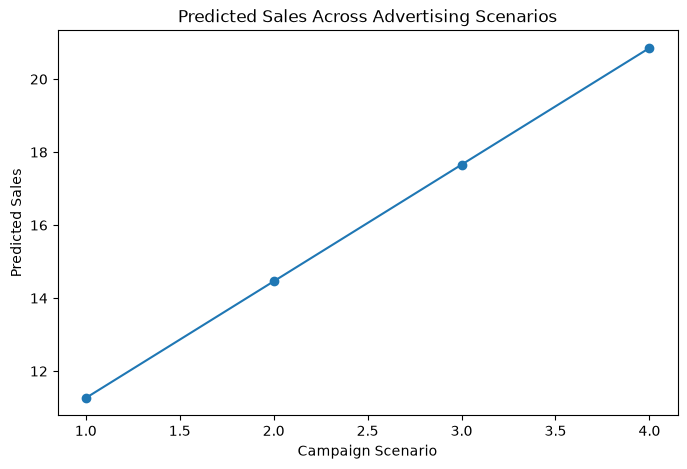

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    campaigns.index + 1,
    campaigns["predicted_sales"],
    marker="o"
)

plt.title("Predicted Sales Across Advertising Scenarios")
plt.xlabel("Campaign Scenario")
plt.ylabel("Predicted Sales")

plt.show()

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = linear_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Accuracy-like percentage
accuracy = r2 * 100

print("Model Evaluation")
print("================")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")
print(f"Accuracy : {accuracy:.2f}%")

Model Evaluation
MAE      : 1.46
RMSE     : 1.78
R² Score : 0.8994
Accuracy : 89.94%


In [47]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score", "Accuracy-like (%)"],
    "Value": [mae, rmse, r2, accuracy]
})

results

,Metric,Value
0,MAE,1.460757
1,RMSE,1.781600
2,R² Score,0.899438
3,Accuracy-like (%),89.943802
